<a href="https://colab.research.google.com/github/Aman1477r/ML-journey/blob/main/House_price_predict_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

In [12]:
df = pd.read_csv("house_data.csv")

In [13]:
df.head()

,area,bedrooms,bathrooms,price
0,800,1,1,40
1,1000,2,1,50
2,1200,2,2,60
3,1500,3,2,75
4,1800,3,2,90


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   area       10 non-null     int64
 1   bedrooms   10 non-null     int64
 2   bathrooms  10 non-null     int64
 3   price      10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [15]:
df.isnull().sum()

,0
area,0
bedrooms,0
bathrooms,0
price,0


In [16]:
df.describe()

,area,bedrooms,bathrooms,price
count,10.000000,10.000000,10.000000,10.00000
mean,1880.000000,3.100000,2.300000,96.50000
std,756.894239,1.197219,0.948683,40.89621
min,800.000000,1.000000,1.000000,40.00000
25%,1275.000000,2.250000,2.000000,63.75000
50%,1900.000000,3.000000,2.000000,95.00000
75%,2425.000000,4.000000,3.000000,126.25000
max,3000.000000,5.000000,4.000000,160.00000


In [17]:
df.duplicated().sum()

np.int64(0)

### SO WE ARER ADDING SOME EDA TO OBSERVE THE DATA


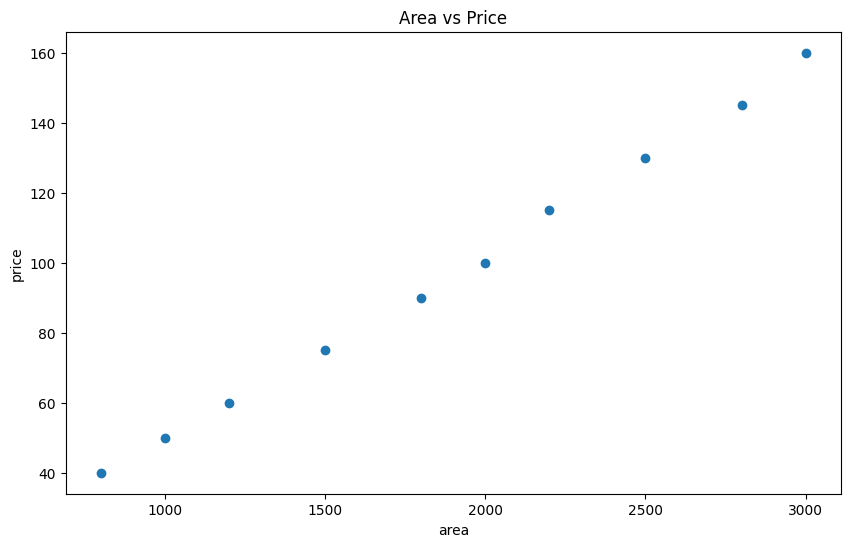

In [18]:
plt.figure(figsize=(10,6)),

plt.scatter(df["area"], df["price"]),

plt.xlabel("area"),

plt.ylabel("price"),

plt.title("Area vs Price")

plt.show()
#

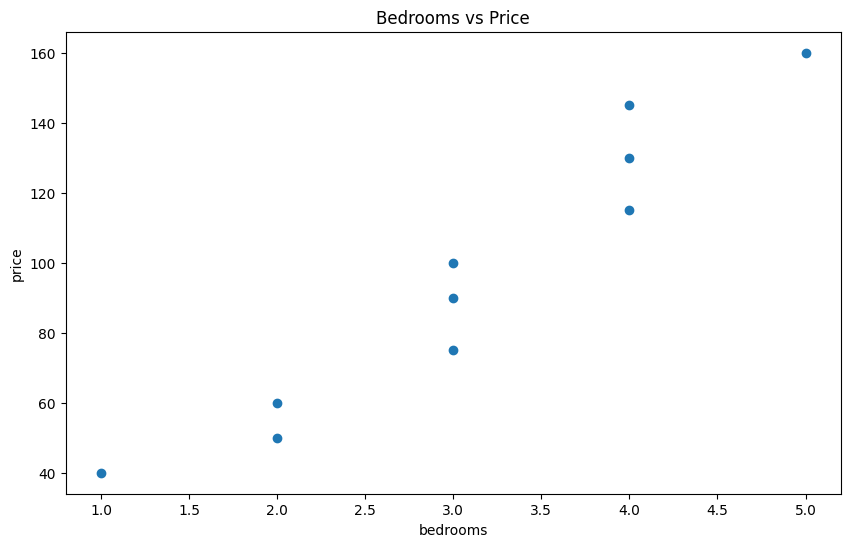

In [19]:
plt.figure(figsize=(10,6)),

plt.scatter(df["bedrooms"], df["price"]),

plt.xlabel("bedrooms"),

plt.ylabel("price"),

plt.title("Bedrooms vs Price")

plt.show()
#

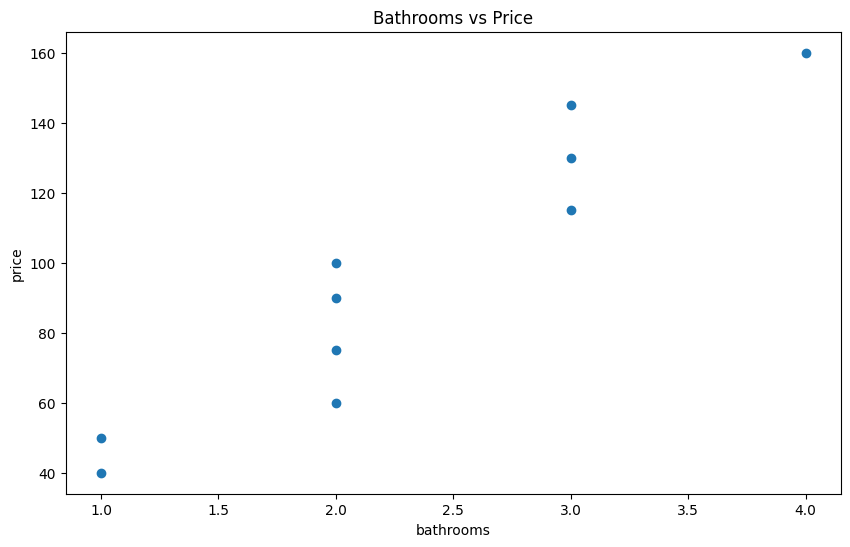

In [20]:
plt.figure(figsize=(10,6)),

plt.scatter(df["bathrooms"], df["price"]),

plt.xlabel("bathrooms"),

plt.ylabel("price"),

plt.title("Bathrooms vs Price")

plt.show()
#

In [21]:
X = df[["area", "bedrooms", "bathrooms"]]
y = df["price"]

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
print("training data" , X_train.shape , y_train.shape)
print("testing data" , X_test.shape , y_test.shape)
#

training data (8, 3) (8,)
testing data (2, 3) (2,)


In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
model = LinearRegression()

In [27]:
model.fit(X_train,y_train)

LinearRegression()

In [28]:
y_pred = model.predict(X_test)

In [29]:
comparison = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
comparison.head()

,Actual,Predicted
8,145,145.825792
1,50,45.622172


In [30]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [31]:
MAE = mean_absolute_error(y_test,y_pred)
MSE = mean_squared_error(y_test,y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test,y_pred)

In [32]:
print("MAE:",MAE)
print("MSE:",MSE)
print("RMSE:",RMSE)
print("R2:",R2)

MAE: 2.6018099547514666
MSE: 9.923655330564166
RMSE: 3.1501833804659953
R2: 0.9956017040086143


In [33]:
new_house = pd.DataFrame({
    "area":[1400],
    "bedrooms":[3],
    "bathrooms":[2]
})


In [34]:
print(new_house)

   area  bedrooms  bathrooms
0  1400         3          2


In [35]:
prediction = model.predict(new_house)
print("prediction price",prediction[0],"lakhs")

prediction price 69.53619909502244 lakhs


In [36]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [37]:
linear_model = LinearRegression()
tree_model = DecisionTreeRegressor(random_state=42)
forest_model = RandomForestRegressor(n_estimators=100,random_state=42)

In [38]:
linear_model.fit(X_train,y_train)
tree_model.fit(X_train,y_train)
forest_model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [39]:
linear_prediction = linear_model.predict(X_test)
tree_prediction = tree_model.predict(X_test)
forest_prediction = forest_model.predict(X_test)

In [40]:
linear_mae = mean_absolute_error(y_test,linear_prediction)
linear_mse = mean_squared_error(y_test,linear_prediction)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test,linear_prediction)

In [41]:
tree_mae = mean_absolute_error(y_test,tree_prediction)
tree_mse = mean_squared_error(y_test,tree_prediction)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test,tree_prediction)

In [42]:
forest_mae = mean_absolute_error(y_test,forest_prediction)
forest_mse = mean_squared_error(y_test,forest_prediction)
forest_rmse = np.sqrt(forest_mse)

In [43]:
print("Linear Regression:")
print("MAE:",linear_mae)
print("MSE:",linear_mse)
print("RMSE:",linear_rmse)
print("R2:",linear_r2)

Linear Regression:
MAE: 2.6018099547514666
MSE: 9.923655330564166
RMSE: 3.1501833804659953
R2: 0.9956017040086143


In [44]:
print("Decision Tree Regression:")
print("MAE:",tree_mae)
print("MSE:",tree_mse)
print("RMSE:",tree_rmse)

Decision Tree Regression:
MAE: 12.5
MSE: 162.5
RMSE: 12.747548783981962


In [45]:
print("Random Forest Regression:")
print("MAE:",forest_mae)
print("MSE:",forest_mse)
print("RMSE:",forest_rmse)

Random Forest Regression:
MAE: 7.699999999999999
MSE: 102.1925
RMSE: 10.109030616236158


In [46]:
result = pd.DataFrame({
    "Model":["Linear Regression","Decision Tree Regression","Random Forest Regression"],
    "MAE":[linear_mae,tree_mae,forest_mae],
    "MSE":[linear_mse,tree_mse,forest_mse],
    "RMSE":[linear_rmse,tree_rmse,forest_rmse]
})

In [47]:
result

,Model,MAE,MSE,RMSE
0,Linear Regression,2.60181,9.923655,3.150183
1,Decision Tree Regression,12.50000,162.500000,12.747549
2,Random Forest Regression,7.70000,102.192500,10.109031


In [48]:
final_model = forest_model

In [49]:
import joblib

In [50]:
joblib.dump(final_model,"House_price_model.pk1")

['House_price_model.pk1']

In [51]:
import os

In [52]:


print(os.path.exists("house_price_model.pkl"))

False


In [53]:
result

,Model,MAE,MSE,RMSE
0,Linear Regression,2.60181,9.923655,3.150183
1,Decision Tree Regression,12.50000,162.500000,12.747549
2,Random Forest Regression,7.70000,102.192500,10.109031


In [54]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 78.9 MB/s eta 0:00:00


In [55]:
!streamlit --version


Streamlit, version 1.64.0


In [56]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Page configuration
st.set_page_config(
    page_title="House Price Prediction",
    page_icon="🏠",
    layout="wide"
)

# Load model and dataset
model = joblib.load("house_price_model.pkl")
df = pd.read_csv("house_data.csv")

# Title
st.title("🏠 House Price Prediction")
st.write(
    "Predict house prices using Machine Learning."
)

# Sidebar
st.sidebar.header("🏡 House Information")

area = st.sidebar.number_input(
    "Area (sq ft)",
    min_value=300,
    max_value=10000,
    value=1500
)

bedrooms = st.sidebar.number_input(
    "Bedrooms",
    min_value=1,
    max_value=10,
    value=3
)

bathrooms = st.sidebar.number_input(
    "Bathrooms",
    min_value=1,
    max_value=10,
    value=2
)

# Prediction
if st.sidebar.button("🔮 Predict Price"):

    input_data = pd.DataFrame({
        "area": [area],
        "bedrooms": [bedrooms],
        "bathrooms": [bathrooms]
    })

    prediction = model.predict(input_data)

    st.success(
        f"Predicted House Price: ₹{prediction[0]:.2f} Lakhs"
    )

# Dataset
st.header("📊 Dataset")

st.dataframe(df)

# Charts
st.header("📈 Data Analysis")

st.subheader("Area vs Price")

st.scatter_chart(
    df,
    x="area",
    y="price"
)

st.subheader("Bedrooms vs Price")

st.scatter_chart(
    df,
    x="bedrooms",
    y="price"
)

st.subheader("Bathrooms vs Price")

st.scatter_chart(
    df,
    x="bathrooms",
    y="price"
)

# About
st.header("ℹ️ About This Project")

st.write("""
This project uses Linear Regression to predict house prices
based on area, bedrooms, and bathrooms.

The project demonstrates an end-to-end Machine Learning workflow:
data exploration, visualization, model training, evaluation,
prediction, and deployment using Streamlit.
""")

Writing app.py


In [57]:
!ls

app.py	drive  house_data.csv  House_price_model.pk1  sample_data


In [58]:
!mv House_price_model.pk1 house_price_model.pkl


In [59]:
!ls

app.py	drive  house_data.csv  house_price_model.pkl  sample_data


In [60]:
import os

print("app.py:", os.path.exists("app.py"))
print("dataset:", os.path.exists("house_data.csv"))
print("model:", os.path.exists("house_price_model.pkl"))

app.py: True
dataset: True
model: True


In [61]:
!streamlit run app.py > /content/streamlit.log 2>&1 &

In [62]:
!ps aux | grep streamlit

root        5602 85.7  0.1  32524 22600 ?        R    14:18   0:00 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root        5607  0.0  0.0   7340  3616 ?        S    14:18   0:00 /bin/bash -c ps aux | grep streamlit
root        5609  0.0  0.0   6544  2304 ?        S    14:18   0:00 grep streamlit


In [63]:
!cat /content/streamlit.log

In [64]:
!curl -I http://localhost:8501

curl: (7) Failed to connect to localhost port 8501 after 2 ms: Couldn't connect to server


In [65]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-usc1c1-39ptp5u8mn9es-c.us-central1-1.prod.colab.dev


In [66]:
!pkill -f "streamlit run app.py"

In [67]:
!streamlit run app.py \
    --server.address 0.0.0.0 \
    --server.port 8501 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    > /content/streamlit.log 2>&1 &

In [68]:
!curl http://localhost:8501/_stcore/health

curl: (7) Failed to connect to localhost port 8501 after 0 ms: Couldn't connect to server


In [69]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-usc1c1-39ptp5u8mn9es-c.us-central1-1.prod.colab.dev


In [70]:
%%writefile requirements.txt

pandas
numpy
scikit-learn
joblib
streamlit

Writing requirements.txt
